In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

In [ ]:
import pandas as pd

df = pd.read_csv("Disease_dataset")

df.head()

,Disease,Fever,Cough,Fatigue,Difficulty Breathing,Age,Gender,Blood Pressure,Cholesterol Level,Outcome Variable
0,Influenza,Yes,No,Yes,Yes,19,Female,Low,Normal,Positive
1,Common Cold,No,Yes,Yes,No,25,Female,Normal,Normal,Negative
2,Eczema,No,Yes,Yes,No,25,Female,Normal,Normal,Negative
3,Asthma,Yes,Yes,No,Yes,25,Male,Normal,Normal,Positive
4,Asthma,Yes,Yes,No,Yes,25,Male,Normal,Normal,Positive


In [ ]:
print("Shape:", df.shape)
print(       )
df.info()
print(       )
df.isnull().sum()
print(    )
df.duplicated().sum()

Shape: (349, 10)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 349 entries, 0 to 348
Data columns (total 10 columns):
 #   Column                Non-Null Count  Dtype 
---  ------                --------------  ----- 
 0   Disease               349 non-null    object
 1   Fever                 349 non-null    object
 2   Cough                 349 non-null    object
 3   Fatigue               349 non-null    object
 4   Difficulty Breathing  349 non-null    object
 5   Age                   349 non-null    int64 
 6   Gender                349 non-null    object
 7   Blood Pressure        349 non-null    object
 8   Cholesterol Level     349 non-null    object
 9   Outcome Variable      349 non-null    object
dtypes: int64(1), object(9)
memory usage: 27.4+ KB




np.int64(49)

In [ ]:
from sklearn.preprocessing import LabelEncoder


le = LabelEncoder()


for col in df.columns:
    if df[col].dtype == 'object':
        df[col] = le.fit_transform(df[col])


df.head()

,Disease,Fever,Cough,Fatigue,Difficulty Breathing,Age,Gender,Blood Pressure,Cholesterol Level,Outcome Variable
0,56,1,0,1,1,19,0,1,2,1
1,24,0,1,1,0,25,0,2,2,0
2,37,0,1,1,0,25,0,2,2,0
3,6,1,1,0,1,25,1,2,2,1
4,6,1,1,0,1,25,1,2,2,1


In [ ]:
# Features
X = df.drop("Disease", axis=1)

# Target
y = df["Disease"]

print("Features Shape:", X.shape)
print("Target Shape:", y.shape)

Features Shape: (349, 9)
Target Shape: (349,)


In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("Training Data:", X_train.shape)
print("Testing Data:", X_test.shape)

Training Data: (279, 9)
Testing Data: (70, 9)


In [ ]:
from sklearn.tree import DecisionTreeClassifier

# Create the model
model = DecisionTreeClassifier(random_state=42)

# Train the model
model.fit(X_train, y_train)

print("Model trained successfully!")

Model trained successfully!


In [ ]:
# Predict on the test data
y_pred = model.predict(X_test)

print("First 10 Predictions:")
print(y_pred[:10])

First 10 Predictions:
[55 44 20 70 42 66 78 36 67 83]


In [ ]:
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(y_test, y_pred)
S
print("Accuracy:", accuracy)

Accuracy: 0.24285714285714285


In [ ]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.00      0.00      0.00         0
           1       0.00      0.00      0.00         2
           2       0.00      0.00      0.00         0
           4       0.00      0.00      0.00         0
           5       0.00      0.00      0.00         0
           6       0.67      0.22      0.33         9
           8       0.00      0.00      0.00         0
           9       0.00      0.00      0.00         0
          10       0.00      0.00      0.00         1
          11       0.00      0.00      0.00         1
          12       0.00      0.00      0.00         1
          13       0.50      0.50      0.50         2
          18       1.00      1.00      1.00         1
          20       1.00      1.00      1.00         1
          21       0.00      0.00      0.00         0
          22       0.00      0.00      0.00         1
          23       0.00      0.00      0.00         1
          24       0.00    

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_

In [ ]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)

print(cm)

[[0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]
 ...
 [0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 1]]


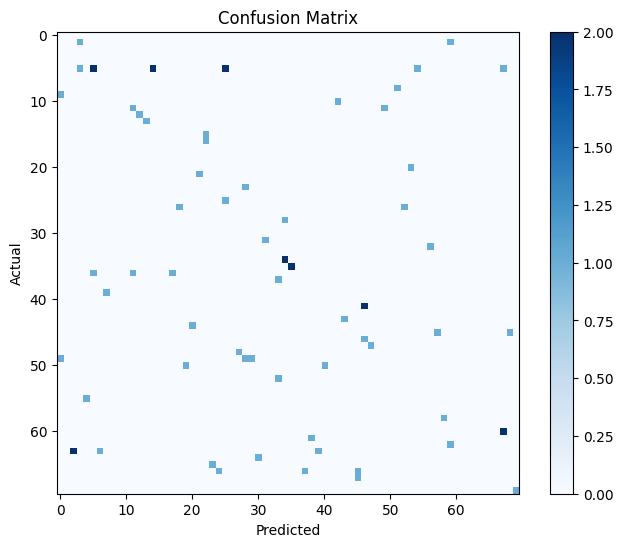

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))
plt.imshow(cm, cmap="Blues")
plt.title("Confusion Matrix")
plt.colorbar()

plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

In [ ]:
import pandas as pd

new_patient = pd.DataFrame({
    "Fever":[1],
    "Cough":[0],
    "Fatigue":[1],
    "Difficulty Breathing":[1],
    "Age":[30],
    "Gender":[1],
    "Blood Pressure":[1],
    "Cholesterol Level":[1],
    "Outcome Variable":[1]
})

prediction = model.predict(new_patient)

print("Predicted Disease Code:", prediction[0])

Predicted Disease Code: 77


In [ ]:
from sklearn.preprocessing import LabelEncoder
import pandas as pd

# Load the original dataset
original_df = pd.read_csv("Disease_dataset")

# Encode only the Disease column
disease_encoder = LabelEncoder()
disease_encoder.fit(original_df["Disease"])

# Convert prediction back to disease name
predicted_name = disease_encoder.inverse_transform(prediction)

print("Predicted Disease:", predicted_name[0])

Predicted Disease: Osteoporosis
